# NB2 — Estimação Individual da Janela Pré-ictal (PELT + K-Means)

**Pipeline de Predição de Crises Epilépticas a partir de EEG**

## Fluxo

```
NB1  →  contextos válidos  +  mapa_contextos_nb1.json  +  .npz
                                       ↓
NB2  →  para cada contexto válido:
         lê EDF original da crise
         extrai trecho contínuo [t_livre, onset]
         PELT + K-Means → PRE_SEC
              ↓
         preictal_estimate.json  (PRE_SEC por paciente)
              ↓
NB3  →  lê .npz + PRE_SEC → 19 features → matrizes rotuladas
              ↓
NB4  →  LOSO por contexto → treino/validação
```

## Lógica central

Para cada crise com contexto válido (conforme NB1), o NB2:

1. Lê o EDF original do arquivo da crise
2. Calcula `t_livre` = fim da crise anterior no mesmo arquivo + GUARD
   (se não houver crise anterior, `t_livre = 0`)
3. Extrai o trecho **contínuo** `[t_livre, onset]` do EDF — sem emendas
4. Aplica PELT sobre as features desse trecho
5. K-Means (k=2) identifica a transição inter → pré-ictal
6. PRE_SEC = quanto tempo antes do onset ocorreu a transição

**Por que não usar o .npz do NB1:**
O .npz contém inter e pre de regiões possivelmente não-contíguas.
Concatená-los criaria uma descontinuidade artificial que o PELT detectaria
imediatamente, resultando em PRE_SEC sempre igual a MAX_PRE.

**Apenas crises com contexto válido no NB1 são analisadas.**
O NB2 não revalida — confia no `mapa_contextos_nb1.json`.


## 1. Imports e configuração

In [1]:
import json, warnings, os, re
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis as kurt
from scipy.signal import welch
from scipy.integrate import trapezoid
import pywt

os.environ['LOKY_MAX_CPU_COUNT'] = '1'
warnings.filterwarnings('ignore')

try:
    import mne
    mne.set_log_level('ERROR')
    HAS_MNE = True
except ImportError:
    HAS_MNE = False; print('pip install mne')

try:
    import ruptures as rpt
    HAS_RUPTURES = True
except ImportError:
    HAS_RUPTURES = False; print('pip install ruptures')

try:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    from sklearn.preprocessing import StandardScaler
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False; print('pip install scikit-learn')

ROOT       = Path('data')
MAP_PATH   = ROOT / 'mapa_contextos_nb1.json'
OUT_PATH   = ROOT / 'preictal_estimate.json'

# Mesmos parâmetros do NB1
GUARD_S   = 30 * 60   # 30 min
MAX_PRE_S = 40 * 60   # 40 min

# Segmentação de features
WIN_S  = 30.0   # janela 30s
STEP_S = 15.0   # passo 15s

# PELT
PELT_MODEL = 'rbf'
PELT_PEN   = 1.5    # reduzido: detecta mais breakpoints

# Filtro de estimativas válidas
PRE_MIN_S  = 5  * 60   # minimo 5 min (< 3min nao e pre-ictal real)
PRE_MAX_S  = 50 * 60   # máximo 50 min
MIN_TRECHO = 3  * 60   # trecho contínuo mínimo para analisar
SILH_MIN   = 0.25   # reduzido: aceita separacoes moderadas

print('Configuração carregada.')

Configuração carregada.


## 2. Carregamento do mapa de contextos (NB1)

In [2]:
if not MAP_PATH.exists():
    raise FileNotFoundError(f'Execute o NB1 primeiro: {MAP_PATH}')

with open(MAP_PATH, encoding='utf-8') as f:
    contexts_map = json.load(f)

from collections import Counter
print(f'Contextos válidos no mapa: {len(contexts_map)}')
for ds, n in Counter(e['dataset'] for e in contexts_map).items():
    n_pat = len(set(e['paciente'] for e in contexts_map if e['dataset']==ds))
    print(f'  {ds}: {n} contextos em {n_pat} pacientes')

# Agrupa por (dataset, paciente)
by_patient = defaultdict(list)
for ctx in contexts_map:
    by_patient[(ctx['dataset'], ctx['paciente'])].append(ctx)

# Também agrupa por (dataset, paciente, arquivo_crise) para saber
# quais crises existem em cada arquivo — necessário para calcular t_livre
by_file = defaultdict(list)
for ctx in contexts_map:
    key = (ctx['dataset'], ctx['paciente'], ctx['arquivo_crise'])
    by_file[key].append(ctx)

print(f'\nTotal pacientes: {len(by_patient)}')

Contextos válidos no mapa: 130
  CHBMIT: 25 contextos em 7 pacientes
  Siena: 21 contextos em 7 pacientes
  SeizeIT2: 77 contextos em 7 pacientes
  Mendeley: 7 contextos em 3 pacientes

Total pacientes: 24


## 3. Ground truth completo (para calcular t_livre)

In [3]:
# ── Por que Siena e Mendeley têm GT hardcoded aqui? ─────────────────────────
#
# CHB-MIT  → tem chb-summary.txt por paciente (formato texto estruturado).
#            parse_chbmit_summary() lê automaticamente.
#
# SeizeIT2 → segue o padrão BIDS: cada EDF tem um *_events.tsv ao lado,
#            com colunas onset/duration/eventType. Lido automaticamente.
#
# Siena    → anotações distribuídas num PDF/Word do dataset, NÃO em arquivo
#            por EDF. Os onsets (em segundos relativos ao início do arquivo)
#            foram calculados manualmente como:
#              onset_s = hms(sz_start_clock) − hms(rec_start_clock)
#            Se negativo, soma-se 86400 (cruzamento da meia-noite).
#            Calculado uma vez e hardcoded aqui e no NB1.
#
# Mendeley → anotações num arquivo Excel/CSV global do dataset, não por EDF.
#            Os onsets (~7200 s) foram extraídos manualmente da documentação.
#            Hardcoded aqui e no NB1.
#
# IMPORTANTE: este GT inclui TODAS as crises de cada arquivo (válidas e
# inválidas no NB1), pois o NB2 precisa delas para calcular t_livre:
#   t_livre = fim_da_última_crise_anterior_no_mesmo_arquivo + GUARD_S
# Se usarmos só as crises válidas do mapa_nb1.json, crises que o NB1
# invalidou ainda contaminam o sinal e precisam ser consideradas.

SIENA_GT = {
    'PN01': {'pn01-1.edf': [(10218,10272),(46353,46427)]},
    'PN05': {'pn05-2.edf':[(7163,7198)],'pn05-3.edf':[(6836,6866)],'pn05-4.edf':[(3608,3647)]},
    'PN09': {'pn09-1.edf':[(7249,7329)],'pn09-2.edf':[(7127,7186)],'pn09-3.edf':[(7221,7285)]},
    'PN10': {
        'pn10-1.edf':[(7545,7614)],'pn10-2.edf':[(7798,7849)],'pn10-3.edf':[(7835,7904)],
        'pn10-4.5.6.edf':[(2309,2314),(6544,6563),(11225,11282)],
        'pn10-7.8.9.edf':[(2748,2796),(5459,5477),(12923,12938)],'pn10-10.edf':[(7977,7991)],
    },
    'PN13': {'pn13-1.edf':[(7062,7110)],'pn13-2.edf':[(7249,7314)],'pn13-3.edf':[(7553,7704)]},
    'PN14': {'pn14-1.edf':[(7262,7289)],'pn14-2.edf':[(7479,7491)],
             'pn14-3.edf':[(17540,17581)],'pn14-4.edf':[(5463,5546)]},
    'PN17': {'pn17-1.edf':[(8420,8490)],'pn17-2.edf':[(7731,7814)]},
}
MENDELEY_GT = {
    'p10': {'p10_record1.edf':[(7199,7644)],'p10_record2.edf':[(7200,7505)]},
    'p13': {'p13_record1.edf':[(7196,7248)],'p13_record2.edf':[(3241,3266),(7196,7212)],
            'p13_record3.edf':[(7240,7258)],'p13_record4.edf':[(1450,1480),(6651,6675)]},
    'p15': {'p15_record1.edf':[(7158,7208)],'p15_record2.edf':[(7147,7194)],
            'p15_record3.edf':[(7132,7145)],'p15_record4.edf':[(2431,2487),(7234,7254)]},
}

def normalize_fn(f): return re.sub(r'-+','-',f.lower())
def siena_match(fn, gt):
    k=normalize_fn(fn)
    if k in gt: return gt[k]
    parts=k.split('-',1)
    if len(parts)==2:
        p,s=parts
        for v in [p.replace('0','o'),p.replace('o','0')]:
            if v+'-'+s in gt: return gt[v+'-'+s]
    return []

def parse_chbmit_summary(path):
    sz_map,free={},[]
    blocks=open(path,errors='ignore').read().split('File Name:')
    for block in blocks[1:]:
        lines=block.strip().split('\n'); fname=lines[0].strip()
        n_sz=0; onsets=[]; offsets=[]
        for ln in lines:
            if 'Number of Seizures' in ln:
                try: n_sz=int(re.search(r'\d+',ln.split(':',1)[1]).group())
                except: pass
            elif 'Seizure' in ln and 'Start Time' in ln:
                mx=re.search(r'(\d+)',ln.split(':',1)[1])
                if mx: onsets.append(int(mx.group()))
            elif 'Seizure' in ln and 'End Time' in ln:
                mx=re.search(r'(\d+)',ln.split(':',1)[1])
                if mx: offsets.append(int(mx.group()))
        if n_sz>0: sz_map[fname]=[(o,e) for o,e in zip(onsets,offsets) if e>o]
        else: free.append(fname)
    return sz_map,free

def get_all_seizures_in_file(dataset, pat, edf_filename):
    """Retorna TODAS as crises do arquivo (válidas e inválidas).
    Necessário para calcular t_livre corretamente.
    """
    fn = edf_filename.lower()
    if dataset == 'Siena':
        gt = SIENA_GT.get(pat, {})
        return siena_match(edf_filename, gt)
    elif dataset == 'Mendeley':
        gt = MENDELEY_GT.get(pat, {})
        return gt.get(fn, [])
    elif dataset in ('CHBMIT','SeizeIT2'):
        # Para CHB-MIT, lê o summary
        if dataset == 'CHBMIT':
            pat_dir = ROOT / 'chb-mit' / pat
            summary = pat_dir / f'{pat}-summary.txt'
            if summary.exists():
                sz_map, _ = parse_chbmit_summary(summary)
                return sz_map.get(edf_filename, [])
        # Para SeizeIT2, lê o TSV de eventos
        elif dataset == 'SeizeIT2':
            import pandas as pd
            eeg_dir = ROOT / 'seizeit2' / pat / 'ses-01' / 'eeg'
            tsv = eeg_dir / edf_filename.replace('_eeg.edf','_events.tsv')
            if tsv.exists():
                try:
                    df = pd.read_csv(tsv, sep='\t')
                    if 'eventType' in df.columns:
                        et = df['eventType'].astype(str).str.lower().str.strip()
                        iv = []
                        for _,row in df[et.str.startswith('sz')].iterrows():
                            try:
                                o=float(row['onset']); d=float(row['duration'])
                                if d>0: iv.append((o,o+d))
                            except: pass
                        return iv
                except: pass
    return []

print('Ground truth e helpers definidos.')

Ground truth e helpers definidos.


## 4. Cálculo de t_livre para cada contexto

`t_livre` = fim da última crise anterior no mesmo arquivo + GUARD.
Se não houver crise anterior: `t_livre = 0`.

O trecho contínuo analisado é `[t_livre, onset]`.


In [4]:
def get_t_livre(ctx):
    """Calcula o início do trecho contínuo limpo antes do onset.

    Considera TODAS as crises do arquivo (não só as válidas),
    porque qualquer crise — mesmo inválida — contamina o sinal.
    """
    dataset   = ctx['dataset']
    pat       = ctx['paciente']
    edf_file  = ctx['arquivo_crise']
    onset_s   = ctx['onset_s']

    # Todas as crises do arquivo
    all_seiz = get_all_seizures_in_file(dataset, pat, edf_file)

    # Crises que terminam antes do onset atual
    prev_seiz = [(on, off) for on, off in all_seiz if off < onset_s]

    if not prev_seiz:
        return 0.0  # nenhuma crise anterior → começa do início

    # Última crise anterior
    last_off = max(off for _, off in prev_seiz)
    t_livre  = last_off + GUARD_S

    # Garante que t_livre não ultrapassa o onset
    return min(t_livre, onset_s)

# Teste com os contextos do mapa
print('Exemplos de t_livre por contexto:')
print(f'  {"Dataset":<10} {"Paciente":<10} {"Arquivo":<25} '
      f'{"Onset (min)":<13} {"t_livre (min)":<14} {"Trecho (min)"}')
print('  ' + '-'*80)
for ctx in contexts_map[:15]:
    tl  = get_t_livre(ctx)
    dur = (ctx['onset_s'] - tl) / 60
    print(f'  {ctx["dataset"]:<10} {ctx["paciente"]:<10} '
          f'{ctx["arquivo_crise"]:<25} '
          f'{ctx["onset_s"]/60:>8.1f}      '
          f'{tl/60:>8.1f}        '
          f'{dur:>6.1f}min')

Exemplos de t_livre por contexto:
  Dataset    Paciente   Arquivo                   Onset (min)   t_livre (min)  Trecho (min)
  --------------------------------------------------------------------------------
  CHBMIT     chb06      chb06_01.edf                 124.3          59.0          65.4min
  CHBMIT     chb06      chb06_01.edf                 225.4         154.6          70.8min
  CHBMIT     chb06      chb06_04.edf                 103.5          35.8          67.7min
  CHBMIT     chb06      chb06_09.edf                 208.3           0.0         208.3min
  CHBMIT     chb06      chb06_10.edf                 180.6           0.0         180.6min
  CHBMIT     chb06      chb06_18.edf                 130.0           0.0         130.0min
  CHBMIT     chb06      chb06_24.edf                 156.4           0.0         156.4min
  CHBMIT     chb04      chb04_05.edf                 130.1           0.0         130.1min
  CHBMIT     chb04      chb04_08.edf                 107.4           0.

## 5. Carregamento do trecho contínuo do EDF

In [5]:
def get_edf_path(ctx):
    """Retorna o Path do EDF da crise."""
    dataset = ctx['dataset']
    pat     = ctx['paciente']
    fn      = ctx['arquivo_crise']
    if dataset == 'CHBMIT':
        return ROOT / 'chb-mit' / pat / fn
    elif dataset == 'Siena':
        return ROOT / 'siena' / pat / fn
    elif dataset == 'SeizeIT2':
        return ROOT / 'seizeit2' / pat / 'ses-01' / 'eeg' / fn
    elif dataset == 'Mendeley':
        p = ROOT / 'mendeley' / 'Raw_EDF_Files' / fn
        if not p.exists(): p = ROOT / 'mendeley' / fn
        return p
    return None


def _read_edf_native(path, tmin, tmax):
    """Le trecho EDF diretamente do arquivo: int16 -> float32.
    Nunca aloca o arquivo inteiro nem usa float64 (evita MemoryError
    do MNE em arquivos grandes). Suporta EDF padrao (nao EDF+).
    Retorna (data, sfreq, ch_names) ou (None, None, None).
    """
    non_eeg = {'spo2','hr','ekg','ecg','emg','eog','mk',
               'status','annot','trig','stim'}

    with open(path, 'rb') as fh:
        # -- Header global (256 bytes) --------------------------------------
        fh.read(8)                                    # versao
        fh.read(80)                                   # paciente
        fh.read(80)                                   # gravacao
        fh.read(8)                                    # data
        fh.read(8)                                    # hora
        n_header_bytes = int(fh.read(8))
        fh.read(44)                                   # reserved
        n_records  = int(fh.read(8))
        record_dur = float(fh.read(8))
        n_signals  = int(fh.read(4))

        # -- Header por sinal --------------------------------------------------
        def _field(size):
            return [fh.read(size).decode('latin-1').strip()
                    for _ in range(n_signals)]

        ch_labels     = _field(16)
        _field(80)                        # transducer
        _field(8)                         # dimension
        phys_min      = [float(x) for x in _field(8)]
        phys_max      = [float(x) for x in _field(8)]
        dig_min       = [float(x) for x in _field(8)]
        dig_max       = [float(x) for x in _field(8)]
        _field(80)                        # prefilter
        samps_per_rec = [int(x) for x in _field(8)]
        _field(32)                        # reserved por sinal

        # -- Seleciona canais EEG ------------------------------------------------
        eeg_idx = [i for i, ch in enumerate(ch_labels)
                   if ch.upper().startswith('EEG')]
        if not eeg_idx:
            eeg_idx = [i for i, ch in enumerate(ch_labels)
                       if not any(kw in ch.lower() for kw in non_eeg)]
        if not eeg_idx:
            eeg_idx = list(range(n_signals))

        sf       = samps_per_rec[eeg_idx[0]] / record_dur
        dur      = n_records * record_dur
        ch_names = [ch_labels[i] for i in eeg_idx]

        # Ganho: int16 -> fisico, ja em float32
        gains   = np.array(
            [(phys_max[i] - phys_min[i]) / max(dig_max[i] - dig_min[i], 1)
             for i in eeg_idx], dtype=np.float32)
        offsets = np.array(
            [phys_min[i] - dig_min[i] * gains[j]
             for j, i in enumerate(eeg_idx)], dtype=np.float32)

        # -- Records necessarios --------------------------------------------------
        tmin = max(0.0, tmin)
        tmax = min(dur,  tmax)
        if tmax - tmin < 1.0:
            return None, None, None

        rec_start = max(0, int(np.floor(tmin / record_dur)))
        rec_end   = min(n_records, int(np.ceil(tmax / record_dur)))
        n_recs    = rec_end - rec_start

        bytes_per_record = sum(s * 2 for s in samps_per_rec)
        fh.seek(n_header_bytes + rec_start * bytes_per_record)

        # -- Le records e monta buffers float32 ------------------------------------
        eeg_set  = set(eeg_idx)
        spr_eeg  = [samps_per_rec[i] for i in eeg_idx]
        buffers  = [np.empty(s * n_recs, dtype=np.float32) for s in spr_eeg]
        pos      = [0] * len(eeg_idx)

        for _ in range(n_recs):
            for sig_i in range(n_signals):
                raw_bytes = fh.read(samps_per_rec[sig_i] * 2)
                if sig_i in eeg_set:
                    j   = eeg_idx.index(sig_i)
                    n   = samps_per_rec[sig_i]
                    arr = np.frombuffer(raw_bytes, dtype=np.int16).astype(np.float32)
                    buffers[j][pos[j]: pos[j] + n] = arr
                    pos[j] += n

        # Aplica ganho -> float32 (nunca passa por float64)
        data = np.stack(buffers, axis=0)          # (n_ch, n_samples) float32
        for j in range(len(eeg_idx)):
            data[j] = data[j] * gains[j] + offsets[j]

        # Corta exatamente para [tmin, tmax]
        s0 = int((tmin - rec_start * record_dur) * sf)
        s1 = s0 + int((tmax - tmin) * sf)
        data = data[:, s0: min(s1, data.shape[1])]

    return data, float(sf), ch_names


def _apply_filters_por_canal(data, sf):
    """Filtra canal a canal para nunca alocar a matriz inteira em float64.
    scipy.sosfilt/filtfilt internamente usam float64 -- para uma matriz
    grande (n_ch x n_amostras) isso dobra (ou mais) o consumo de memoria.
    Processando uma linha 1D por vez, o float64 temporario fica limitado
    a uma unica linha, nao a matriz inteira.
    """
    from scipy.signal import butter, sosfilt, iirnotch, filtfilt

    target_sf = 256.0
    do_resample = abs(sf - target_sf) > 1
    if do_resample:
        from scipy.signal import resample_poly
        from math import gcd
        rn, rd = int(target_sf), int(sf)
        g = gcd(rn, rd)
        sf_eff = target_sf
    else:
        sf_eff = sf

    sos_hp = butter(4, 0.5,  btype='high', fs=sf_eff, output='sos')
    sos_lp = butter(4, 40.0, btype='low',  fs=sf_eff, output='sos')
    notch_filters = []
    for f0 in [50.0, 60.0]:
        if f0 < sf_eff / 2:
            notch_filters.append(iirnotch(f0, Q=30, fs=sf_eff))

    n_ch = data.shape[0]
    out = None

    for ch in range(n_ch):
        row = data[ch]                          # 1D float32, view
        if do_resample:
            row = resample_poly(row, rn // g, rd // g).astype(np.float32)

        row = sosfilt(sos_hp, row).astype(np.float32)
        row = sosfilt(sos_lp, row).astype(np.float32)
        for b, a in notch_filters:
            row = filtfilt(b, a, row).astype(np.float32)

        if out is None:
            out = np.empty((n_ch, row.shape[0]), dtype=np.float32)
        out[ch] = row

    return out, sf_eff


def load_trecho(ctx, t_livre, verbose=False):
    """Carrega EDF[t_livre : onset] via leitura nativa (sem MNE, sem float64).
    Filtragem tambem e feita canal a canal para nao alocar a matriz
    inteira em float64 durante scipy.sosfilt/filtfilt.
    """
    path = get_edf_path(ctx)
    if path is None or not path.exists():
        if verbose: print(f'    EDF nao encontrado: {path}')
        return None, None, None
    try:
        def _scale_uv(data):
            mv = np.max(np.abs(data))
            if mv == 0: return None
            if mv < 0.001: data = data * 1e6
            elif mv < 1.0: data = data * 1e3
            return data

        tmin = max(0.0, float(t_livre))
        tmax = float(ctx['onset_s'])

        data, sf, ch_names = _read_edf_native(path, tmin, tmax)

        if data is None or data.size == 0: return None, None, None
        data = _scale_uv(data)
        if data is None: return None, None, None

        data, sf = _apply_filters_por_canal(data, sf)
        return data, sf, ch_names

    except MemoryError as e:
        if verbose: print(f'    MemoryError {Path(str(path)).name}: {e}')
        return None, None, None
    except Exception as e:
        if verbose: print(f'    Erro {Path(str(path)).name}: {e}')
        return None, None, None

print('Loader de trecho definido (leitura EDF nativa + filtragem por canal, sem MNE, sem float64 na matriz inteira).')


Loader de trecho definido (leitura EDF nativa + filtragem por canal, sem MNE, sem float64 na matriz inteira).


## 6. Extração de features — 19 por canal (idênticas ao NB3)

| # | Feature | Categoria |
|---|---|---|
| 1 | Desvio padrão | Temporal |
| 2 | Variância | Temporal |
| 3 | RMS | Temporal |
| 4 | Comprimento de linha | Temporal |
| 5 | Mobilidade de Hjorth | Temporal |
| 6 | Skewness | Temporal |
| 7 | Curtose | Temporal |
| 8 | Delta (0.5–4 Hz) | Espectral |
| 9 | Theta (4–8 Hz) | Espectral |
| 10 | Alpha (8–13 Hz) | Espectral |
| 11 | Beta (13–30 Hz) | Espectral |
| 12 | Gamma (30–40 Hz) | Espectral |
| 13 | Entropia espectral | Espectral |
| 14 | Beta relativo | Espectral |
| 15 | Energia wavelet d1 | Wavelet |
| 16 | Energia wavelet d2 | Wavelet |
| 17 | Energia wavelet d3 | Wavelet |
| 18 | Energia wavelet d4 | Wavelet |
| 19 | Complexidade de Hjorth | Complexidade |


In [6]:
def extract_features_window(window, sfreq):
    """19 features por canal. window: (n_ch, n_amostras)."""
    feats = []
    for ch in window:
        std   = np.std(ch)
        diff1 = np.diff(ch); std_d1 = np.std(diff1)
        mob   = std_d1 / (std + 1e-10)

        feats += [std, np.var(ch), np.sqrt(np.mean(ch**2)),
                  np.sum(np.abs(diff1)), mob,
                  float(skew(ch)), float(kurt(ch))]

        f, psd = welch(ch, fs=sfreq, nperseg=min(len(ch), int(sfreq*4)))
        def bp(lo, hi):
            idx = np.logical_and(f>=lo, f<=hi)
            return float(trapezoid(psd[idx], f[idx])) if idx.any() else 0.0
        d,t,a,b,g = bp(0.5,4),bp(4,8),bp(8,13),bp(13,30),bp(30,40)
        tot = d+t+a+b+g+1e-10
        pn  = psd/(psd.sum()+1e-10); pn=pn[pn>0]
        feats += [d,t,a,b,g, float(-np.sum(pn*np.log2(pn))), b/tot]

        c = pywt.wavedec(ch, 'db4', level=4)
        feats += [float(np.sum(c[4]**2)), float(np.sum(c[3]**2)),
                  float(np.sum(c[2]**2)), float(np.sum(c[1]**2))]

        diff2  = np.diff(diff1)
        mob_d1 = np.std(diff2)/(std_d1+1e-10)
        feats.append(mob_d1/(mob+1e-10))
    return np.array(feats, dtype=np.float32)

def build_feature_matrix(signal, sfreq):
    """Segmenta (n_ch, n_samp) em janelas de WIN_S/STEP_S e extrai features.
    Retorna (feat_matrix [n_win, n_feats], t_centers [n_win] em segundos).
    t_centers é relativo ao início do trecho (t_livre).
    """
    win_n  = int(WIN_S  * sfreq)
    step_n = int(STEP_S * sfreq)
    feats, centers = [], []
    n_samp = signal.shape[1]
    for start in range(0, n_samp - win_n + 1, step_n):
        feats.append(extract_features_window(signal[:, start:start+win_n], sfreq))
        centers.append((start + win_n/2) / sfreq)
    return np.array(feats), np.array(centers)

print('Features OK (19 por canal).')

Features OK (19 por canal).


## 7. Estimação por contexto — PELT + K-Means

O trecho `[t_livre, onset]` é contínuo e sem emendas.
O PELT detecta descontinuidades na série de features.
O K-Means (k=2) identifica dois estados: interictal e pré-ictal.
PRE_SEC = `onset - t_breakpoint` (em segundos).


In [7]:
def estimate_preictal(signal, sfreq, onset_s, t_livre):
    """Estima PRE_SEC no trecho contínuo [t_livre, onset].

    signal : (n_ch, n_samp) — trecho já filtrado, em µV
    sfreq  : frequência de amostragem
    onset_s: onset em segundos no arquivo original (para referência)
    t_livre: início do trecho em segundos no arquivo original

    Retorna dict com pre_sec e metadados.
    """
    if not HAS_RUPTURES or not HAS_SKLEARN:
        return {'pre_sec': None, 'motivo': 'dependencia faltando'}

    dur_trecho = signal.shape[1] / sfreq

    feat_matrix, t_centers = build_feature_matrix(signal, sfreq)
    n_win = len(feat_matrix)

    if n_win < 6:
        return {'pre_sec': None, 'n_windows': n_win,
                'dur_trecho_min': round(dur_trecho/60,1),
                'motivo': f'poucos segmentos ({n_win}, min=6)'}

    # Remove features constantes
    std_f = np.std(feat_matrix, axis=0)
    valid = std_f > 1e-10
    if valid.sum() < 3:
        return {'pre_sec': None, 'n_windows': n_win,
                'motivo': 'features constantes'}

    X      = feat_matrix[:, valid]
    X_norm = StandardScaler().fit_transform(X)

    # PELT
    try:
        algo = rpt.Pelt(model=PELT_MODEL).fit(X_norm)
        bkps = algo.predict(pen=PELT_PEN)
        bkps = [b for b in bkps if 0 < b < n_win]

        # Descarta breakpoints no primeiro MAX_PRE_S do trecho
        # (pre-ictal nao pode comecar mais de MAX_PRE antes do onset)
        min_bkp_s = dur_trecho - MAX_PRE_S  # so breakpoints apos esse ponto
        min_bkp_win = int(min_bkp_s / WIN_S * 2)  # aprox em janelas
        bkps_filtrados = [b for b in bkps if t_centers[b] >= max(0, min_bkp_s)]
        if not bkps_filtrados:
            bkps_filtrados = bkps  # fallback: usa todos se nenhum passar
    except Exception as e:
        return {'pre_sec': None, 'n_windows': n_win,
                'motivo': f'PELT erro: {e}'}

    if not bkps:
        return {'pre_sec': None, 'n_windows': n_win,
                'changepoints': [], 'motivo': 'PELT sem mudanca'}
    bkps = bkps_filtrados  # aplica filtro de zona relevante

    # K-Means k=2
    try:
        km    = KMeans(n_clusters=2, random_state=42, n_init='auto')
        labels = km.fit_predict(X_norm)
        if len(set(labels)) < 2:
            return {'pre_sec': None, 'n_windows': n_win,
                    'changepoints': bkps, 'motivo': 'cluster unico'}
        sil = silhouette_score(X_norm, labels)
    except Exception as e:
        return {'pre_sec': None, 'n_windows': n_win,
                'changepoints': bkps, 'motivo': f'KMeans erro: {e}'}

    if sil < SILH_MIN:
        return {'pre_sec': None, 'silhouette': float(sil),
                'n_windows': n_win, 'changepoints': bkps,
                'motivo': f'Silhouette={sil:.3f} < {SILH_MIN}'}

    # Identifica o cluster pré-ictal:
    # o que domina nas janelas mais próximas do onset (últimas 1/3)
    last_third = labels[int(n_win*2/3):]
    if len(last_third) == 0:
        return {'pre_sec': None, 'silhouette': float(sil),
                'n_windows': n_win, 'changepoints': bkps,
                'motivo': 'sem janelas no ultimo terceiro'}
    pre_cluster = int(np.bincount(last_third).argmax())

    # Breakpoint mais próximo do onset (último breakpoint relevante)
    # que marque a transição para o cluster pré-ictal
    bkp_times_s = [t_centers[b] for b in bkps]

    # Busca o breakpoint onde começa a zona dominada pelo pre_cluster
    transition_idx = None
    for bp_idx in reversed(bkps):
        # janelas a partir desse breakpoint
        after = labels[bp_idx:]
        if len(after) > 0 and np.bincount(after).argmax() == pre_cluster:
            transition_idx = bp_idx
            break
    if transition_idx is None:
        transition_idx = bkps[-1]

    t_transition = t_centers[transition_idx]  # em s desde t_livre

    # PRE_SEC = tempo desde a transição até o onset
    pre_sec = float(dur_trecho - t_transition)

    if not (PRE_MIN_S <= pre_sec <= PRE_MAX_S):
        return {'pre_sec': None, 'silhouette': float(sil),
                'n_windows': n_win, 'changepoints': bkps,
                'dur_trecho_min': round(dur_trecho/60,1),
                't_transition_min': round(t_transition/60,1),
                'motivo': f'pre_sec={pre_sec/60:.1f}min fora de '
                          f'[{PRE_MIN_S//60},{PRE_MAX_S//60}]min'}

    return {
        'pre_sec':         pre_sec,
        'pre_min':         round(pre_sec/60, 2),
        'silhouette':      float(sil),
        'n_windows':       n_win,
        'changepoints':    bkps,
        'dur_trecho_min':  round(dur_trecho/60, 1),
        't_transition_min': round(t_transition/60, 1),
        'pre_cluster':     pre_cluster,
        'motivo':          f'OK — pre_sec={pre_sec/60:.1f}min sil={sil:.3f}',
    }

print('Função de estimação definida.')

Função de estimação definida.


## 8. Estimação para todos os pacientes

In [8]:
results = {}

# -- Checkpoint: carrega resultados anteriores -------------------------------
CHECKPOINT = OUT_PATH.parent / 'preictal_estimate_checkpoint.json'
if CHECKPOINT.exists():
    with open(CHECKPOINT, encoding='utf-8') as f:
        prev = json.load(f)
    for r in prev:
        results[(r['dataset'], r['paciente'])] = r
    done = [f"{r['dataset']}/{r['paciente']}" for r in prev]
    print(f'Checkpoint: {len(results)} pacientes carregados: {done}\n')

print('Estimando janela pre-ictal por paciente...\n')

for (dataset, pat), ctx_list in sorted(by_patient.items()):

    # Contextos ja processados com resultado definitivo (nao-EDF)
    estimativas_prev = {}
    if (dataset, pat) in results:
        for e in results[(dataset, pat)].get('estimativas', []):
            cid = e['contexto_id']
            motivo = e.get('motivo', '')
            if ('falha ao carregar EDF' not in motivo
                    and 'MemoryError' not in motivo
                    and 'Erro' not in motivo):
                estimativas_prev[cid] = e

    n_pendentes = sum(1 for ctx in ctx_list
                      if ctx['contexto_id'] not in estimativas_prev)

    if n_pendentes == 0:
        r = results[(dataset, pat)]
        pre_str = f'{r["pre_min"]:.1f}min' if r.get('pre_min') else 'None'
        print(f'--- {dataset}/{pat}: JA PROCESSADO (PRE_SEC={pre_str}) ---')
        continue

    print(f'--- {dataset}/{pat} ({len(ctx_list)} contextos, {n_pendentes} pendentes) ---')
    estimativas = []

    for ctx in ctx_list:
        cid = ctx['contexto_id']

        # Reutiliza contexto ja processado com sucesso
        if cid in estimativas_prev:
            est = estimativas_prev[cid]
            print(f'  ctx#{cid}: reutilizado — {est["motivo"]}')
            estimativas.append(est)
            continue

        t_livre = get_t_livre(ctx)
        dur_disponivel = (ctx['onset_s'] - t_livre) / 60

        if ctx['onset_s'] - t_livre < MIN_TRECHO:
            est = {'contexto_id': cid,
                   'pre_sec': None,
                   'dur_trecho_min': round(dur_disponivel, 1),
                   'motivo': f'trecho={dur_disponivel:.1f}min < {MIN_TRECHO//60}min'}
            estimativas.append(est)
            print(f'  ctx#{cid}: {est["motivo"]}')
            continue

        signal, sfreq, ch_names = load_trecho(ctx, t_livre, verbose=True)
        if signal is None:
            est = {'contexto_id': cid,
                   'pre_sec': None, 'motivo': 'falha ao carregar EDF'}
            estimativas.append(est)
            print(f'  ctx#{cid}: {est["motivo"]}')
            continue

        est = estimate_preictal(signal, sfreq, ctx['onset_s'], t_livre)
        est['contexto_id']    = cid
        est['dur_trecho_min'] = round((ctx['onset_s'] - t_livre) / 60, 1)
        estimativas.append(est)
        print(f'  ctx#{cid} [trecho={est["dur_trecho_min"]}min]: {est["motivo"]}')

    validas = [e['pre_sec'] for e in estimativas if e.get('pre_sec') is not None]
    pre_sec = float(np.median(validas)) if validas else None
    pre_min = round(pre_sec / 60, 2) if pre_sec else None

    result = {
        'dataset':     dataset,
        'paciente':    pat,
        'pre_sec':     pre_sec,
        'pre_min':     pre_min,
        'n_contextos': len(ctx_list),
        'n_validas':   len(validas),
        'estimativas': estimativas,
        'silhouettes': [e['silhouette'] for e in estimativas
                        if e.get('silhouette') is not None],
    }
    results[(dataset, pat)] = result

    if pre_sec:
        print(f'  => PRE_SEC = {pre_min:.1f}min (mediana de {len(validas)} validas)')
    else:
        print(f'  => PRE_SEC = None')

    with open(CHECKPOINT, 'w', encoding='utf-8') as f:
        json.dump(list(results.values()), f, indent=2, ensure_ascii=False)
    print(f'  [checkpoint: {len(results)}/{len(by_patient)} pacientes]\n')

print(f'Concluido para {len(results)} pacientes.')


Estimando janela pre-ictal por paciente...

--- CHBMIT/chb04 (2 contextos, 2 pendentes) ---
  ctx#1 [trecho=130.1min]: OK — pre_sec=17.3min sil=0.836
  ctx#2 [trecho=107.4min]: pre_sec=2.2min fora de [5,50]min
  => PRE_SEC = 17.3min (mediana de 1 validas)
  [checkpoint: 1/24 pacientes]

--- CHBMIT/chb06 (7 contextos, 7 pendentes) ---
  ctx#1 [trecho=65.4min]: Silhouette=0.183 < 0.25
  ctx#2 [trecho=70.8min]: Silhouette=0.169 < 0.25
  ctx#3 [trecho=67.7min]: OK — pre_sec=13.7min sil=0.289
  ctx#4 [trecho=208.3min]: pre_sec=0.6min fora de [5,50]min
  ctx#5 [trecho=180.6min]: Silhouette=0.232 < 0.25
  ctx#6 [trecho=130.0min]: Silhouette=0.213 < 0.25
  ctx#7 [trecho=156.4min]: pre_sec=2.5min fora de [5,50]min
  => PRE_SEC = 13.7min (mediana de 1 validas)
  [checkpoint: 2/24 pacientes]

--- CHBMIT/chb07 (3 contextos, 3 pendentes) ---
  ctx#1 [trecho=82.0min]: pre_sec=4.2min fora de [5,50]min
  ctx#2 [trecho=54.8min]: OK — pre_sec=32.0min sil=0.369
  ctx#3 [trecho=228.1min]: OK — pre_sec=5.4

## 9. Tabela de resultados e distribuição global

In [9]:
print('RESULTADOS PRE_SEC POR PACIENTE')
print('='*65)
print(f'  {"Dataset":<12} {"Paciente":<12} {"PRE_SEC (min)":<15}'
      f'{"N válidas":<12} {"Silh médio"}')
print('  ' + '-'*60)

pre_sec_all = []
for (dataset, pat), r in sorted(results.items()):
    pre_str  = f'{r["pre_min"]:.1f}' if r['pre_min'] else 'N/A'
    silh_med = (f'{np.mean(r["silhouettes"]):.3f}'
                if r['silhouettes'] else 'N/A')
    print(f'  {dataset:<12} {pat:<12} {pre_str:<15}'
          f'{r["n_validas"]:<12} {silh_med}')
    if r['pre_sec'] is not None:
        pre_sec_all.append(r['pre_sec'])

print('  ' + '-'*60)
if pre_sec_all:
    pm = np.array(pre_sec_all)/60
    print(f'\n  N pacientes com PRE_SEC válido: {len(pm)}/{len(results)}')
    print(f'  Min    : {pm.min():.1f} min')
    print(f'  P25    : {np.percentile(pm,25):.1f} min')
    print(f'  Mediana: {np.median(pm):.1f} min')
    print(f'  P75    : {np.percentile(pm,75):.1f} min')
    print(f'  Max    : {pm.max():.1f} min')
    print()
    p25=round(np.percentile(pm,25))
    p50=round(np.median(pm))
    p75=round(np.percentile(pm,75))
    pmax=round(pm.max())
    print(f'  Janelas fixas sugeridas para NB4:')
    print(f'    W1={p25}min  W2={p50}min  W3={p75}min  W4={pmax}min')
    print(f'    W5=PRE_SEC individual do paciente')

RESULTADOS PRE_SEC POR PACIENTE
  Dataset      Paciente     PRE_SEC (min)  N válidas    Silh médio
  ------------------------------------------------------------
  CHBMIT       chb04        17.3           1            0.686
  CHBMIT       chb06        13.7           1            0.253
  CHBMIT       chb07        18.7           2            0.406
  CHBMIT       chb08        N/A            0            0.232
  CHBMIT       chb10        9.0            4            0.367
  CHBMIT       chb13        N/A            0            0.533
  CHBMIT       chb14        18.2           1            0.259
  Mendeley     p10          18.5           2            0.444
  Mendeley     p13          N/A            0            0.283
  Mendeley     p15          N/A            0            0.312
  SeizeIT2     sub-002      9.3            6            0.698
  SeizeIT2     sub-034      12.8           5            0.694
  SeizeIT2     sub-035      6.5            3            0.731
  SeizeIT2     sub-039      N/A 

## 10. Visualização — série de features e ponto de transição


CHBMIT/chb04 — ctx#1


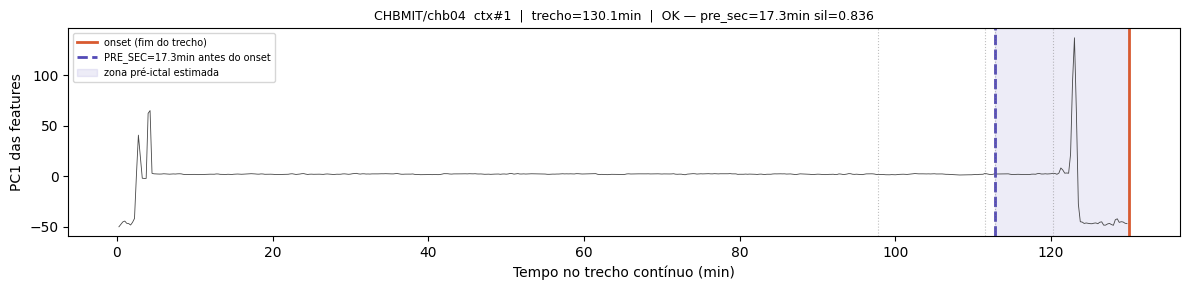


CHBMIT/chb06 — ctx#3


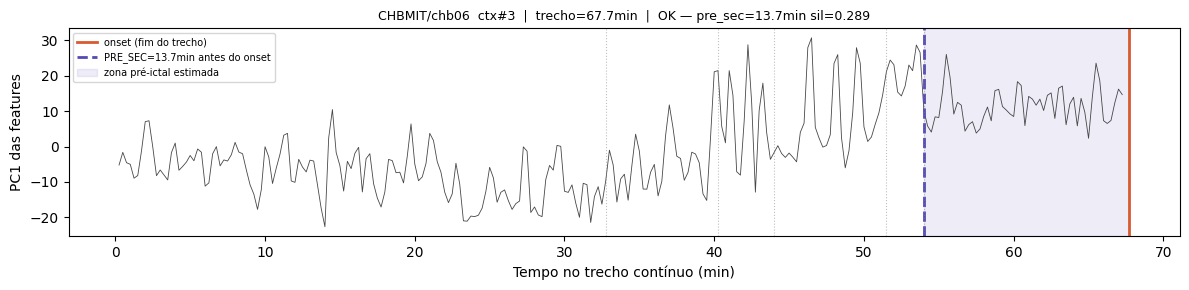


CHBMIT/chb07 — ctx#2


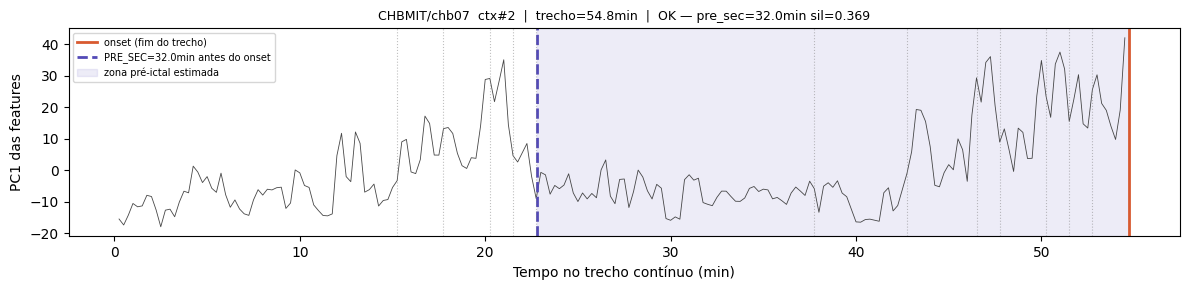


CHBMIT/chb07 — ctx#3


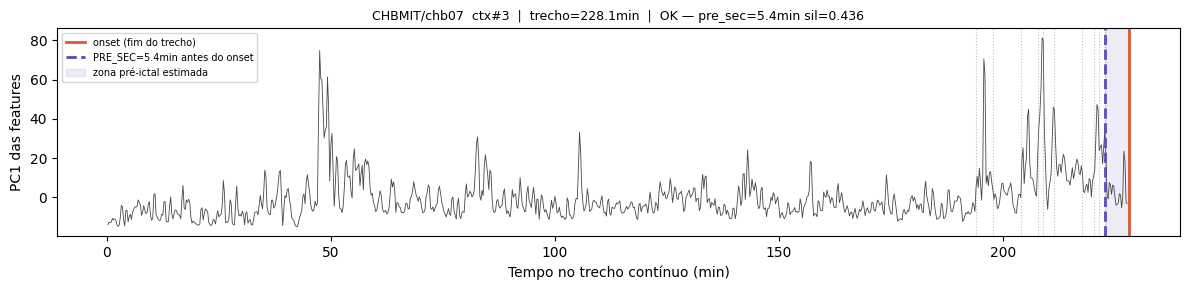


CHBMIT/chb10 — ctx#1


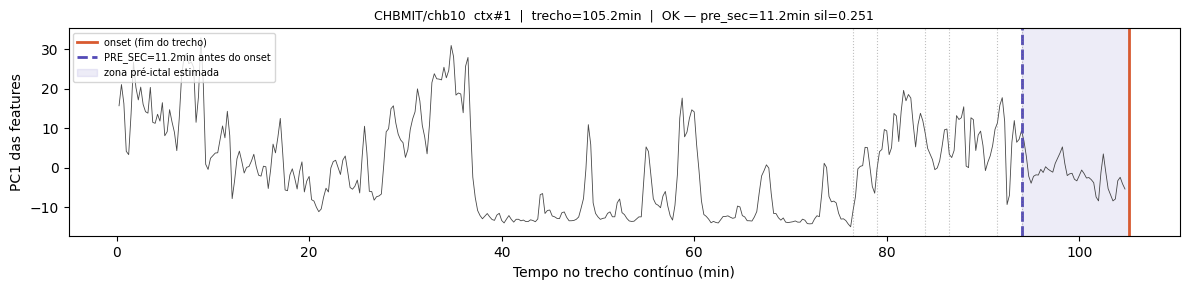


CHBMIT/chb10 — ctx#3


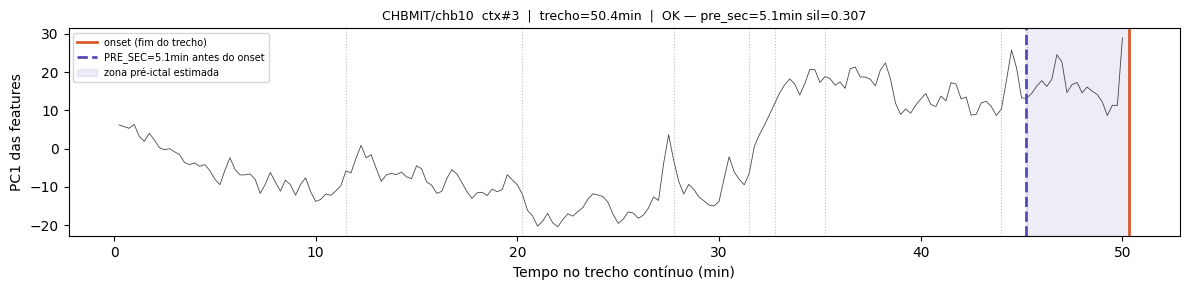


CHBMIT/chb14 — ctx#2


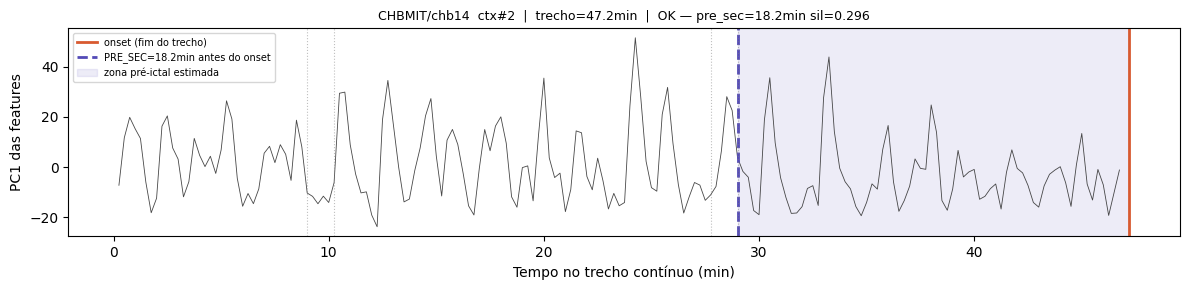


Mendeley/p10 — ctx#1


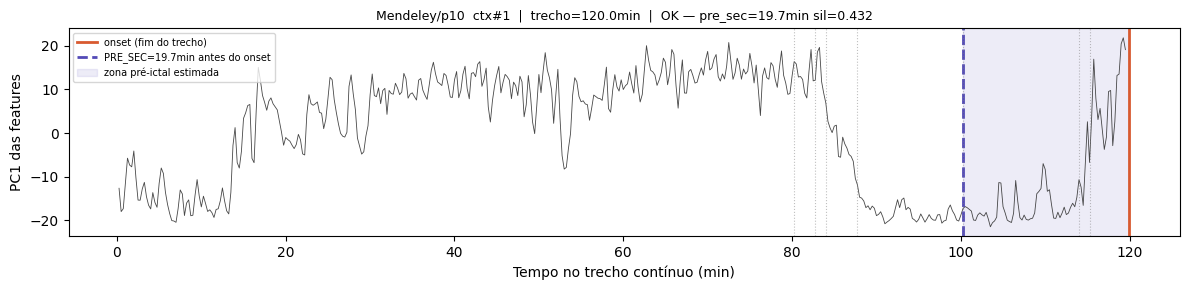


Mendeley/p10 — ctx#2


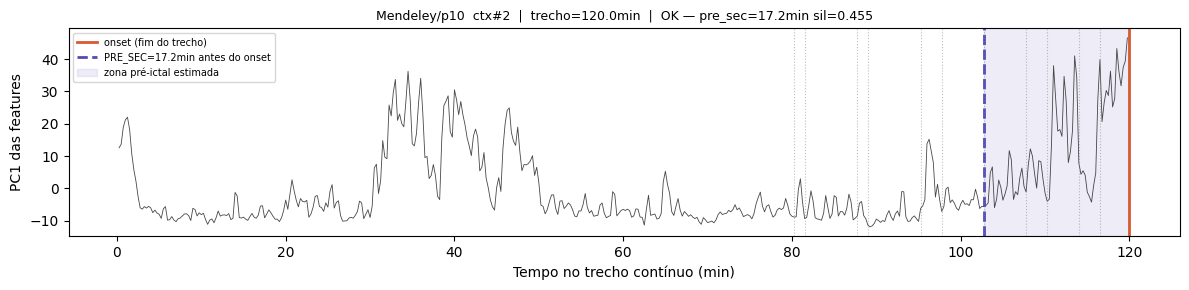


SeizeIT2/sub-002 — ctx#2


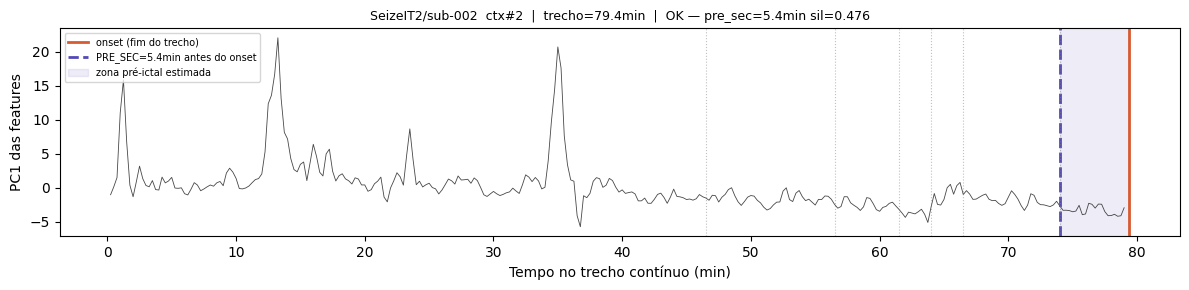


SeizeIT2/sub-002 — ctx#7


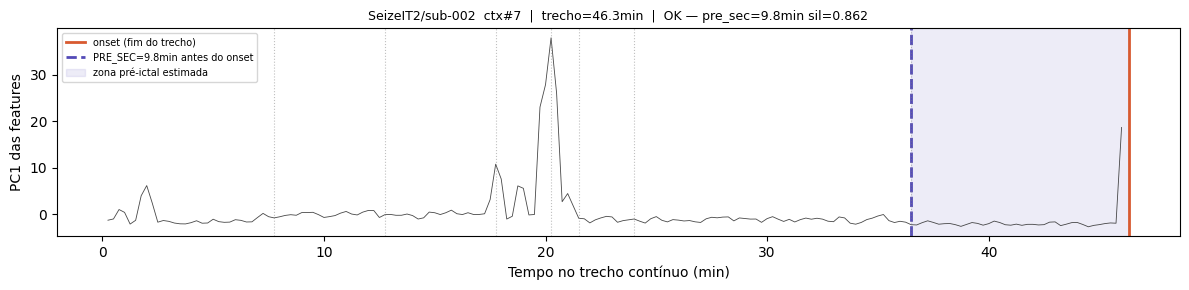


SeizeIT2/sub-034 — ctx#2


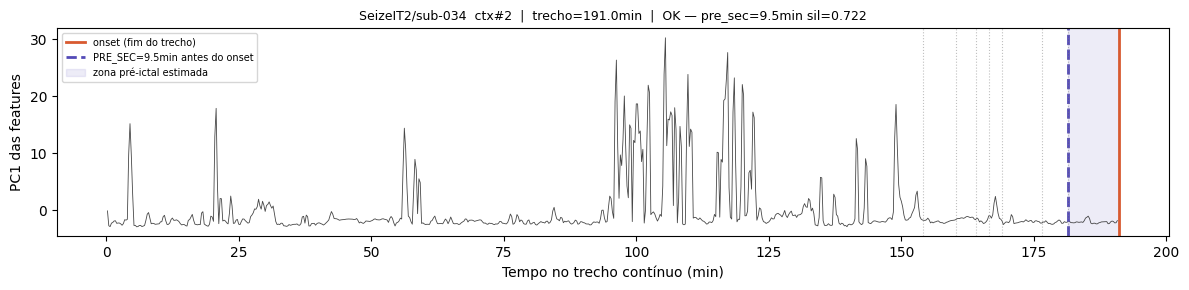


SeizeIT2/sub-034 — ctx#3


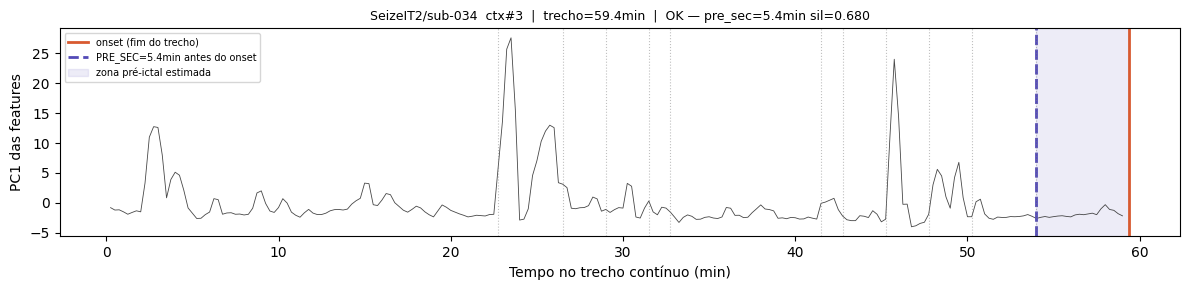


SeizeIT2/sub-035 — ctx#2


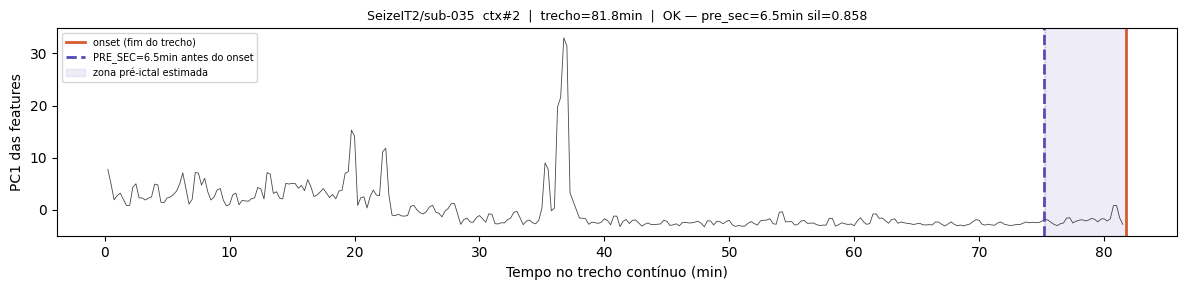


SeizeIT2/sub-035 — ctx#4


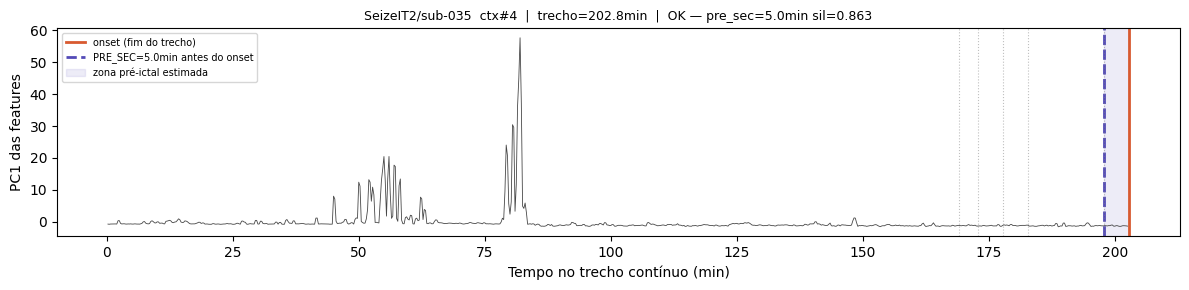


SeizeIT2/sub-047 — ctx#1


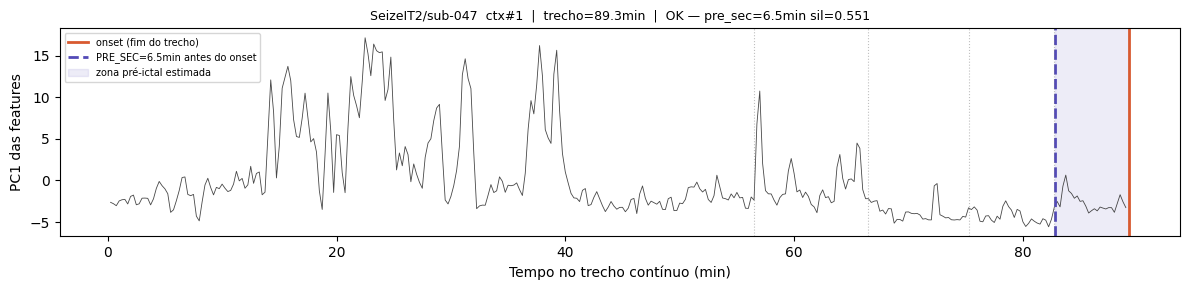


SeizeIT2/sub-047 — ctx#2


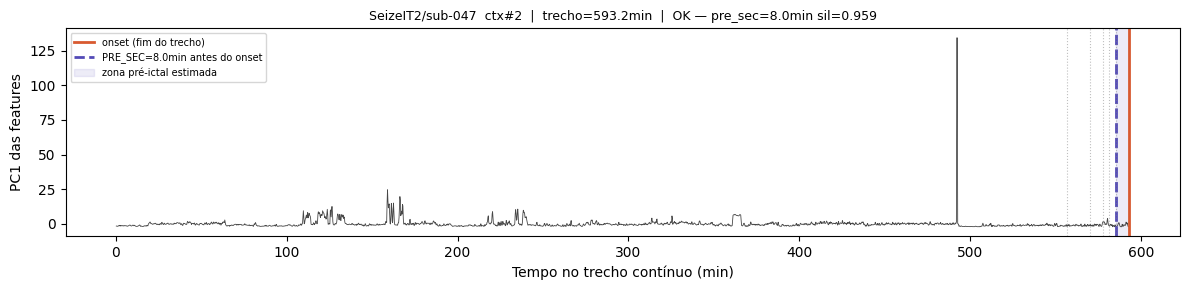


SeizeIT2/sub-072 — ctx#4


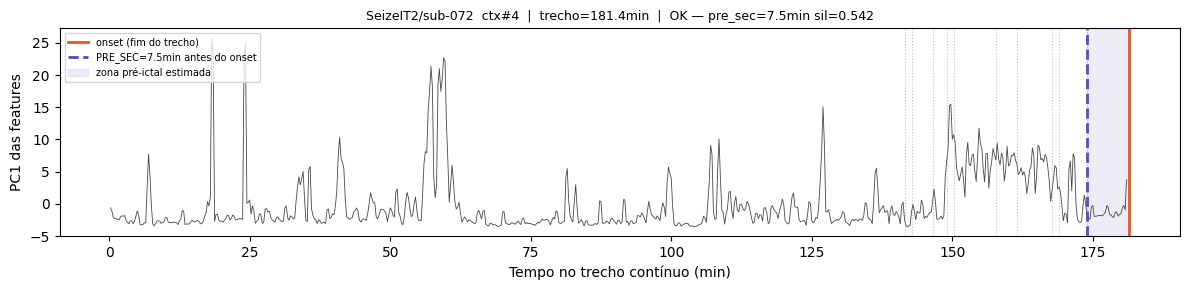


SeizeIT2/sub-072 — ctx#7


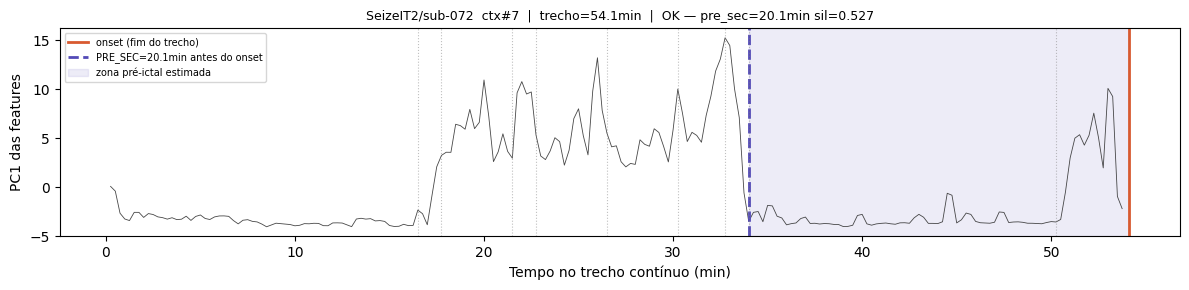


SeizeIT2/sub-073 — ctx#6


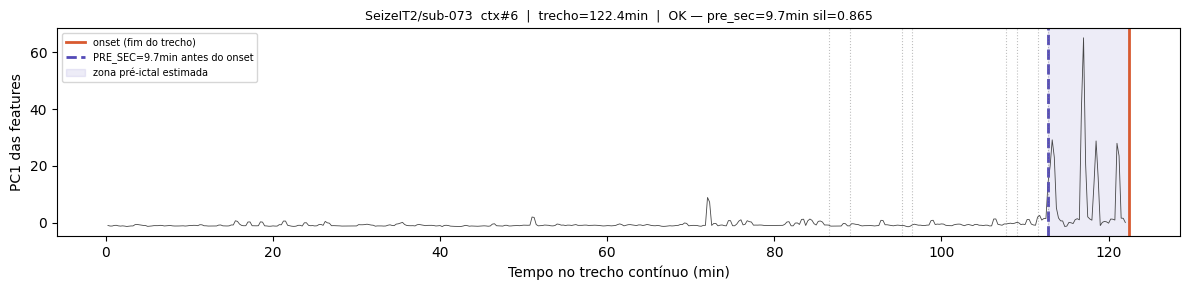


SeizeIT2/sub-073 — ctx#8


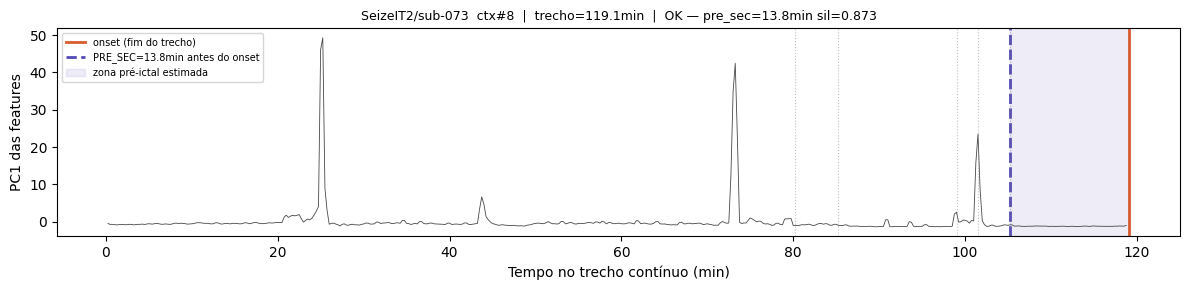


Siena/PN01 — ctx#1


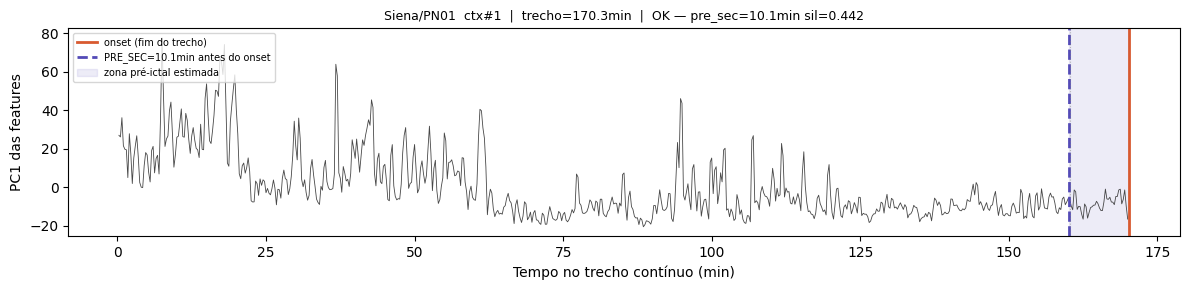


Siena/PN09 — ctx#3


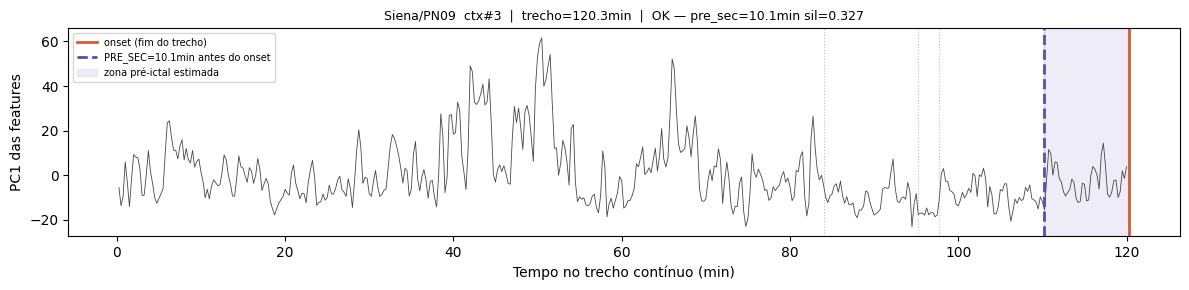


Siena/PN10 — ctx#3


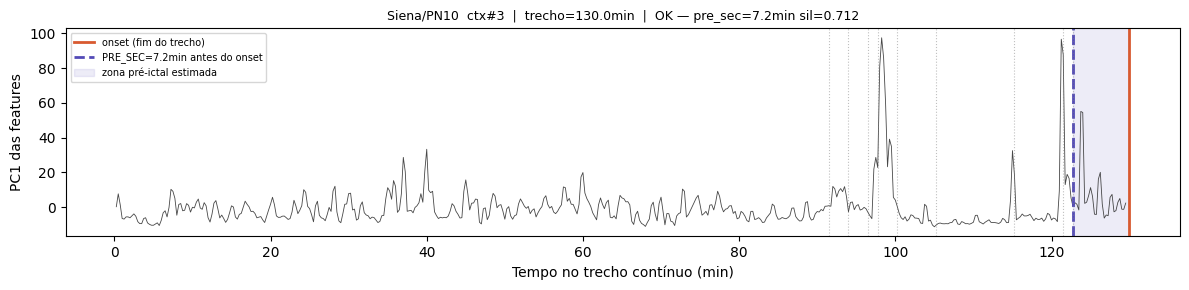


Siena/PN13 — ctx#3


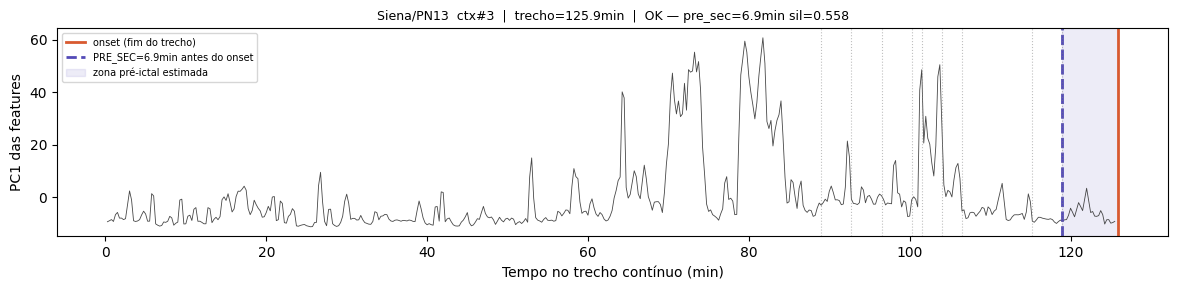


Siena/PN14 — ctx#2


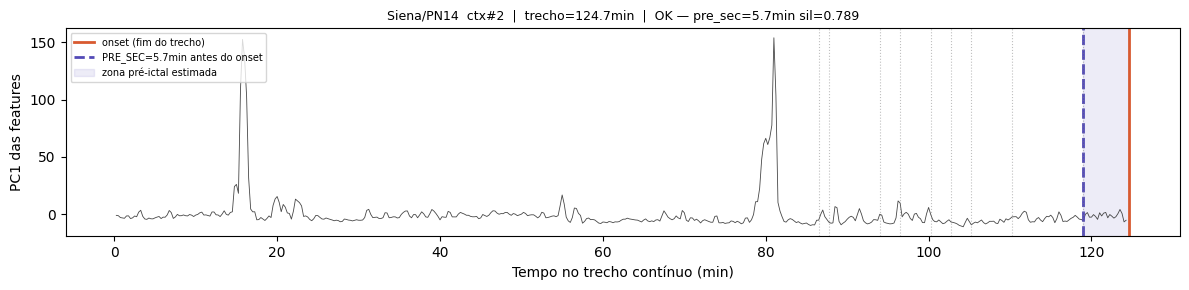


Siena/PN14 — ctx#3


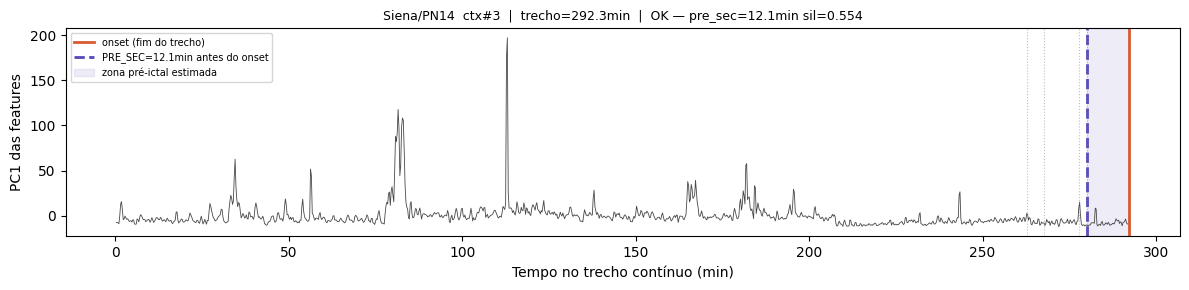


Siena/PN17 — ctx#1


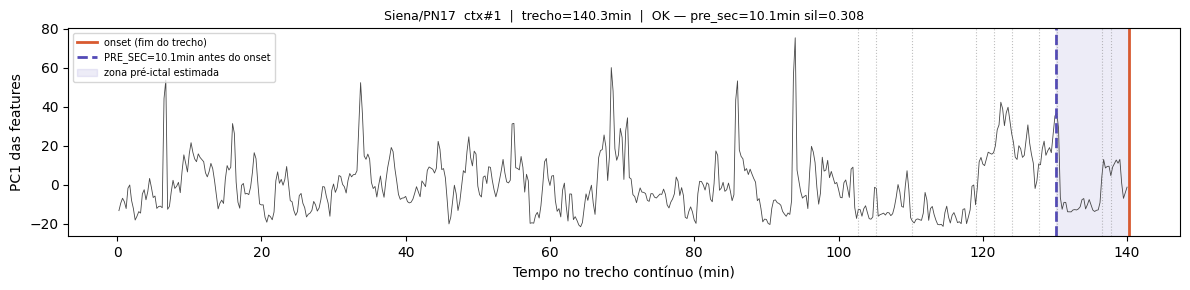

In [10]:
def plot_estimation(dataset, pat, ctx, est):
    """Plota PC1 das features com breakpoint e PRE_SEC estimado."""
    from sklearn.decomposition import PCA
    t_livre = get_t_livre(ctx)
    signal, sfreq, _ = load_trecho(ctx, t_livre)
    if signal is None: print('  Sinal não disponível'); return

    feat_matrix, t_centers = build_feature_matrix(signal, sfreq)
    std_f  = np.std(feat_matrix, axis=0)
    X      = feat_matrix[:, std_f > 1e-10]
    X_norm = StandardScaler().fit_transform(X)
    pc1    = PCA(n_components=1).fit_transform(X_norm)[:,0]

    dur_trecho = signal.shape[1]/sfreq
    t_min = t_centers/60
    onset_min = dur_trecho/60

    fig, ax = plt.subplots(figsize=(12,3))
    ax.plot(t_min, pc1, color='#333', lw=0.6, alpha=0.9)
    ax.axvline(onset_min, color='#D85A30', lw=2, ls='-',
               label='onset (fim do trecho)')

    if est.get('pre_sec') is not None:
        t_trans = est['t_transition_min']
        ax.axvline(t_trans, color='#534AB7', lw=2, ls='--',
                   label=f'PRE_SEC={est["pre_min"]:.1f}min antes do onset')
        ax.axvspan(t_trans, onset_min, color='#534AB7', alpha=0.10,
                   label='zona pré-ictal estimada')

    for bp in est.get('changepoints',[]):
        if 0 < bp < len(t_min):
            ax.axvline(t_min[bp], color='gray', lw=0.8, ls=':', alpha=0.5)

    ax.set_xlabel('Tempo no trecho contínuo (min)')
    ax.set_ylabel('PC1 das features')
    ax.set_title(f'{dataset}/{pat}  ctx#{ctx["contexto_id"]}  |  '
                 f'trecho={est.get("dur_trecho_min","?")}min  |  '
                 f'{est["motivo"]}', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    plt.tight_layout(); plt.show()

MAX_PLOT = 2
for (dataset, pat), r in sorted(results.items()):
    plotados = 0
    for ctx, est in zip(by_patient[(dataset,pat)], r['estimativas']):
        if est.get('pre_sec') is None: continue
        print(f'\n{dataset}/{pat} — ctx#{ctx["contexto_id"]}')
        plot_estimation(dataset, pat, ctx, est)
        plotados += 1
        if plotados >= MAX_PLOT: break

## 11. Exportação do preictal_estimate.json

In [11]:
output = []
for (dataset, pat), r in sorted(results.items()):
    output.append({
        'dataset':     dataset,
        'paciente':    pat,
        'pre_sec':     r['pre_sec'],
        'pre_min':     r['pre_min'],
        'n_contextos': r['n_contextos'],
        'n_validas':   r['n_validas'],
        'silh_medio':  (float(np.mean(r['silhouettes']))
                        if r['silhouettes'] else None),
        'estimativas_por_contexto': [
            {
                'contexto_id':      e['contexto_id'],
                'pre_sec':          e.get('pre_sec'),
                'pre_min':          round(e['pre_sec']/60,2) if e.get('pre_sec') else None,
                'silhouette':       e.get('silhouette'),
                'dur_trecho_min':   e.get('dur_trecho_min'),
                't_transition_min': e.get('t_transition_min'),
                'n_windows':        e.get('n_windows'),
                'motivo':           e.get('motivo',''),
            }
            for e in r['estimativas']
        ],
    })

with open(OUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

n_com = sum(1 for r in output if r['pre_sec'] is not None)
print(f'Salvo em: {OUT_PATH}')
print(f'Pacientes com PRE_SEC válido: {n_com}/{len(output)}')

try:
    from google.colab import files
    files.download(str(OUT_PATH))
except ImportError:
    print(f'Arquivo: {OUT_PATH.resolve()}')

Salvo em: data\preictal_estimate.json
Pacientes com PRE_SEC válido: 18/24
Arquivo: D:\TCC\data\preictal_estimate.json
